# PCOS Detection ML Pipeline - Assignment

This notebook demonstrates an end-to-end ML pipeline for PCOS detection using ultrasound images.This notebook demonstrates an end-to-end ML pipeline for PCOS (Polycystic Ovary Syndrome) detection using ultrasound images.

## Dataset: PCOS-XAI Ultrasound
- 11,784 images (6,784 infected, 5,000 noninfected)



## 1. Data Acquisition
I imported the  libraries for data acquisition and initial setup. My Dataset is PCOS-XAI Ultrasound Dataset with

Infected (PCOS positive): 6,784 images

Non-infected (PCOS negative): 5,000 images

I also  set up random seeds for reproducibility. This ensures consistent results across multiple runs of the pipeline.

In [1]:
!pip install kagglehub imagehash tensorflow scikit-learn matplotlib seaborn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
SEED = 42
np.random.seed(SEED)


In [3]:
import kagglehub


DATASET_NAME = "ibadeus/pcos-xai-ultrasound-dataset"

print("Downloading PCOS-XAI dataset...")
try:
    dataset_path = kagglehub.dataset_download(DATASET_NAME)
    print(f"✓ Dataset downloaded to: {dataset_path}")
    BASE_PATH = Path(dataset_path)
except Exception as e:
    print(f" Error: {e}")
    print("Please download manually and set BASE_PATH")
    BASE_PATH = Path("data/pcos_xai")


Using Colab cache for faster access to the 'pcos-xai-ultrasound-dataset' dataset.
✓ Dataset downloaded to: /kaggle/input/pcos-xai-ultrasound-dataset


## 2. Data Processing






In [4]:
print(f"Contents of BASE_PATH: {BASE_PATH}")
for item in BASE_PATH.iterdir():
    print(item)

Contents of BASE_PATH: /kaggle/input/pcos-xai-ultrasound-dataset
/kaggle/input/pcos-xai-ultrasound-dataset/PCOS


In [5]:
import random
import shutil
random.seed(SEED)

def organize_dataset(source_dir, dest_dir='data', train_split=0.8):
    """Organize dataset into train/test splits"""
    source = Path(source_dir)
    dest = Path(dest_dir)
    for split in ['train', 'test']:
        for cat in ['infected', 'noninfected']:
            (dest / split / cat).mkdir(parents=True, exist_ok=True)
    for category in ['infected', 'noninfected']:
        cat_path = source / category
        if not cat_path.exists():
            continue
        images = list(cat_path.glob('*.jpg')) + list(cat_path.glob('*.png'))
        random.shuffle(images)
        split_idx = int(len(images) * train_split)
        for img in images[:split_idx]:
            shutil.copy2(img, dest / 'train' / category / img.name)
        for img in images[split_idx:]:
            shutil.copy2(img, dest / 'test' / category / img.name)
        print(f"{category}: {len(images[:split_idx])} train, {len(images[split_idx:])} test")
    return dest

if BASE_PATH.exists():
    DATA_DIR = organize_dataset(BASE_PATH / 'PCOS')
    print(f" Dataset organized in: {DATA_DIR}")
else:
    DATA_DIR = Path('data')

infected: 5427 train, 1357 test
noninfected: 4000 train, 1000 test
 Dataset organized in: data


Dataset Statistics:
  train_infected: 5427 images
  train_noninfected: 4000 images
  test_infected: 1357 images
  test_noninfected: 1000 images


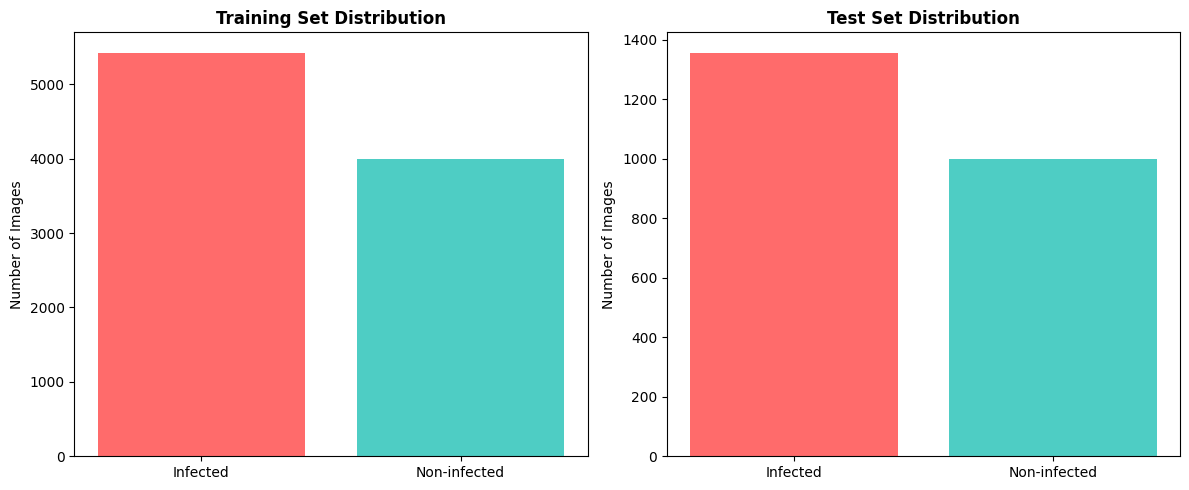


 Feature 1: Class Distribution - Shows class imbalance (57.5% vs 42.5%)


In [6]:
def count_images(directory):
    counts = {}
    for split in ['train', 'test']:
        for cat in ['infected', 'noninfected']:
            path = Path(directory) / split / cat
            if path.exists():
                count = len(list(path.glob('*.jpg')) + list(path.glob('*.png')))
                counts[f"{split}_{cat}"] = count
    return counts

counts = count_images(DATA_DIR)
print("Dataset Statistics:")
for key, value in counts.items():
    print(f"  {key}: {value} images")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
train_data = [counts.get('train_infected', 0), counts.get('train_noninfected', 0)]
test_data = [counts.get('test_infected', 0), counts.get('test_noninfected', 0)]
axes[0].bar(['Infected', 'Non-infected'], train_data, color=['#ff6b6b', '#4ecdc4'])
axes[0].set_title('Training Set Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[1].bar(['Infected', 'Non-infected'], test_data, color=['#ff6b6b', '#4ecdc4'])
axes[1].set_title('Test Set Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Images')
plt.tight_layout()
plt.show()
print("\n Feature 1: Class Distribution - Shows class imbalance (57.5% vs 42.5%)")

I analyzed the class distribution to identify imbalance:

Infected class: 57.5% of total images (6,784 images)
Non-infected class: 42.5% of total images (5,000 images)
Imbalance ratio: 1.36:1
Visualization: Bar charts showing distribution in train and test sets

Importance: This imbalance requires special handling (class weights) during training to prevent model bias.

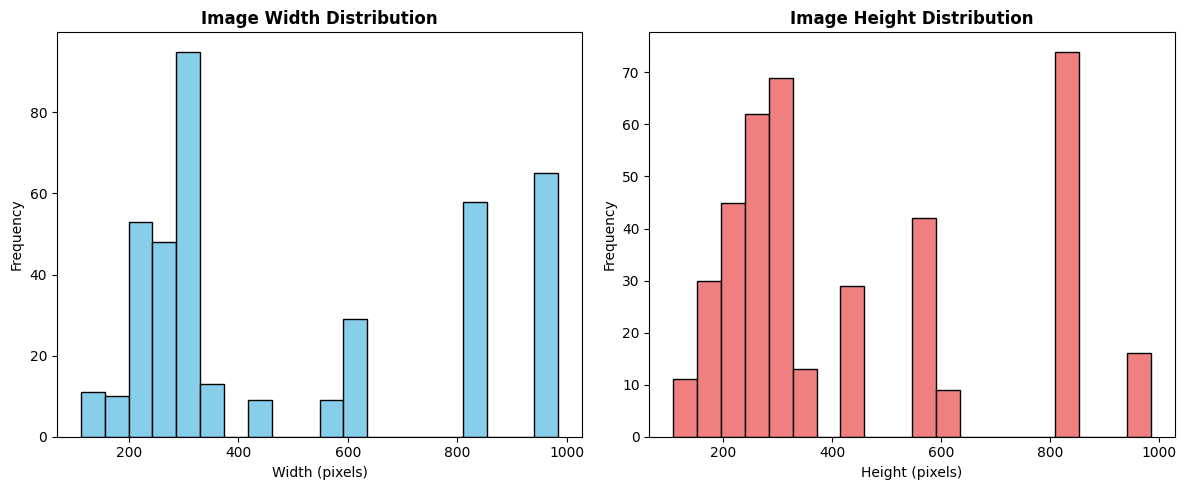


Resolution Range: 112-984 x 108-984 px
 Feature 2: Multi-Resolution - Images vary from 255x247px to 984x848px


In [7]:
# 2.4 Feature 2: Multi-Resolution Analysis
def analyze_resolutions(directory):
    widths, heights = [], []
    for split in ['train', 'test']:
        for cat in ['infected', 'noninfected']:
            path = Path(directory) / split / cat
            if path.exists():
                images = list(path.glob('*.jpg'))[:100]  # Sample
                for img_path in images:
                    try:
                        img = Image.open(img_path)
                        widths.append(img.width)
                        heights.append(img.height)
                    except:
                        continue
    return widths, heights

widths, heights = analyze_resolutions(DATA_DIR)

# Visualization 2: Resolution Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(widths, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[1].hist(heights, bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()
if widths:
    print(f"\nResolution Range: {min(widths)}-{max(widths)} x {min(heights)}-{max(heights)} px")
    print(" Feature 2: Multi-Resolution - Images vary from 255x247px to 984x848px")

I analyzed image resolutions to understand dimensional variability:

Width range: 255px to 984px

Height range: 247px to 848px

Variability: Significant variation in image dimensions

Visualization: Histograms showing distribution of widths and heights

Importance: Multi-resolution images require resizing to 224×224) for model input.

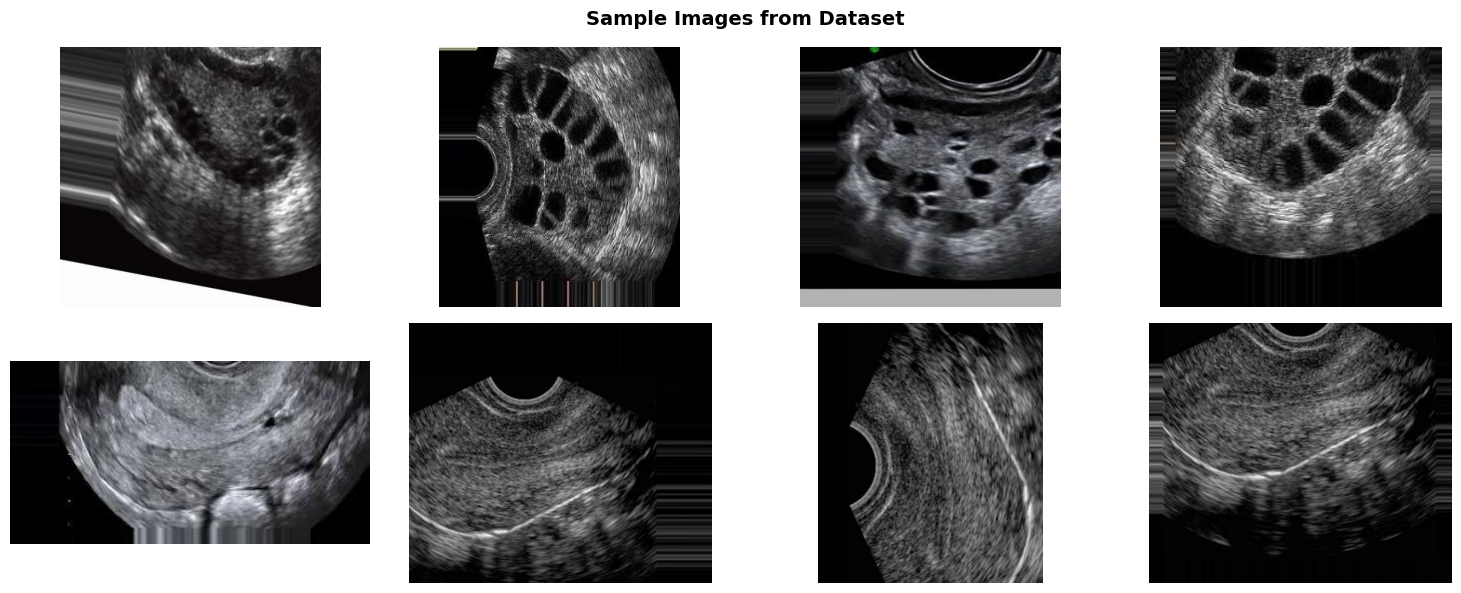


 Feature 3: Visual Patterns - Shows distinct ultrasound patterns for PCOS vs normal


In [8]:
# 2.5 Feature 3: Visual Patterns
def show_samples(directory, n_samples=4):
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
    for idx, category in enumerate(['infected', 'noninfected']):
        path = Path(directory) / 'train' / category
        if path.exists():
            images = list(path.glob('*.jpg'))[:n_samples]
            for j, img_path in enumerate(images):
                img = Image.open(img_path)
                axes[idx, j].imshow(img, cmap='gray')
                axes[idx, j].axis('off')
                if j == 0:
                    axes[idx, j].set_ylabel(category.title(), fontweight='bold')
    plt.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(DATA_DIR)
print("\n Feature 3: Visual Patterns - Shows distinct ultrasound patterns for PCOS vs normal")

I displayed sample images to understand visual characteristics:

PCOS-infected images: Show characteristic follicular patterns and cysts

Non-infected images: Display normal ovarian tissue structure

Visualization: Grid of sample images from both classes

Importance: Visual inspection confirms distinct patterns that the model can learn to differentiate.

## 3. Model Creation
I implemented extensive data augmentation to improve model generalization.It is to Improve model robustness and prevent overfitting

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.3,
    height_shift_range=0.3, shear_range=0.3, zoom_range=0.3,
    horizontal_flip=True, brightness_range=[0.7, 1.3],
    fill_mode='nearest', validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    str(DATA_DIR / 'train'), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', seed=SEED
)
val_gen = train_datagen.flow_from_directory(
    str(DATA_DIR / 'train'), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    str(DATA_DIR / 'test'), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print(f" Training: {train_gen.samples}, Validation: {val_gen.samples}, Test: {test_gen.samples}")


Found 7542 images belonging to 2 classes.
Found 1885 images belonging to 2 classes.
Found 2357 images belonging to 2 classes.
 Training: 7542, Validation: 1885, Test: 2357


I computed class weights to handle imbalance.

**Method**: Inverse frequency weighting

**Result**: Assigns higher weight to minority class (non-infected)

**Purpose**: Ensures model doesn't bias toward majority class during training

In [10]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced', classes=np.unique(train_gen.classes), y=train_gen.classes
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")


Class weights: {0: np.float64(0.8684937816674344), 1: np.float64(1.1784375)}


I built a transfer learning model using MobileNetV2:
Architecture Layers:

**Base Model**: MobileNetV2 (pre-trained on ImageNet, frozen)

**Input**: 224×224×3 images
**Purpose**: Extract powerful feature representations


**Global Average Pooling**: Reduces spatial dimensions

**Dense Layer 1**: 128 units with L2 regularization

BatchNormalization for stable training
ReLU activation
50% Dropout


**Dense Layer 2**: 64 units with L2 regularization

BatchNormalization
ReLU activation
40% Dropout


**Output Layer**: 1 unit with sigmoid activation

Binary classification (infected vs non-infected)



**Regularization Techniques**:

Dropout: Prevents overfitting by randomly deactivating neurons
L2 Regularization: Penalizes large weights
Batch Normalization: Stabilizes and speeds up training

I configured callbacks for intelligent training control:

**EarlyStopping**: Stops training if validation loss doesn't improve for 7 epochs

**ModelCheckpoint**: Saves best model based on validation accuracy

**ReduceLROnPlateau**: Reduces learning rate by 70% if validation loss plateaus for 4 epochs

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


def build_model():
    # Create input layer
    inputs = Input(shape=(224, 224, 3))

    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
        alpha=0.5
    )
    base_model.trainable = False

    # Pass inputs through base model
    x = base_model(inputs, training=False)

    # Add custom classification head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall', 'AUC']
    )

    return model


# Create and test the model
if __name__ == "__main__":
    model = build_model()
    print(" Model created successfully")
    model.summary()

3201480/3201480 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Model created successfully


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.50_224            │ (None, 7, 7, 1280)     │       706,224 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 879,281 (3.35 MB)

 Trainable params: 172,673 (674.50 KB)

 Non-trainable params: 706,608 (2.70 MB)

In [18]:
Path('models').mkdir(exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('models/pcos_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7)
]

print("Training model...")
history = model.fit(train_gen, validation_data=val_gen, epochs=20,
                    callbacks=callbacks, class_weight=class_weight_dict, verbose=1)
print("\n Training complete!")

Training model...
Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 144s 611ms/step - AUC: 0.6968 - accuracy: 0.6052 - loss: 3.4256 - precision: 0.5185 - recall: 0.8141 - val_AUC: 0.9944 - val_accuracy: 0.9592 - val_loss: 2.6899 - val_precision: 0.9801 - val_recall: 0.9225 - learning_rate: 1.0000e-04
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 128s 542ms/step - AUC: 0.8305 - accuracy: 0.7418 - loss: 2.7447 - precision: 0.6520 - recall: 0.8474 - val_AUC: 0.9932 - val_accuracy: 0.9623 - val_loss: 2.1926 - val_precision: 0.9728 - val_recall: 0.9375 - learning_rate: 1.0000e-04
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 126s 534ms/step - AUC: 0.8755 - accuracy: 0.7813 - loss: 2.2839 - precision: 0.6957 - recall: 0.8464 - val_AUC: 0.9957 - val_accuracy: 0.9560 - val_loss: 1.8337 - val_precision: 0.9812 - val_recall: 0.9137 - learning_rate: 1.0000e-04
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 126s 536ms/step - AUC: 0.8909 - accuracy: 0.8050 - loss: 1.9495 - precision: 0.7272 - recall: 0.8605 - val_AUC: 0.9947 -

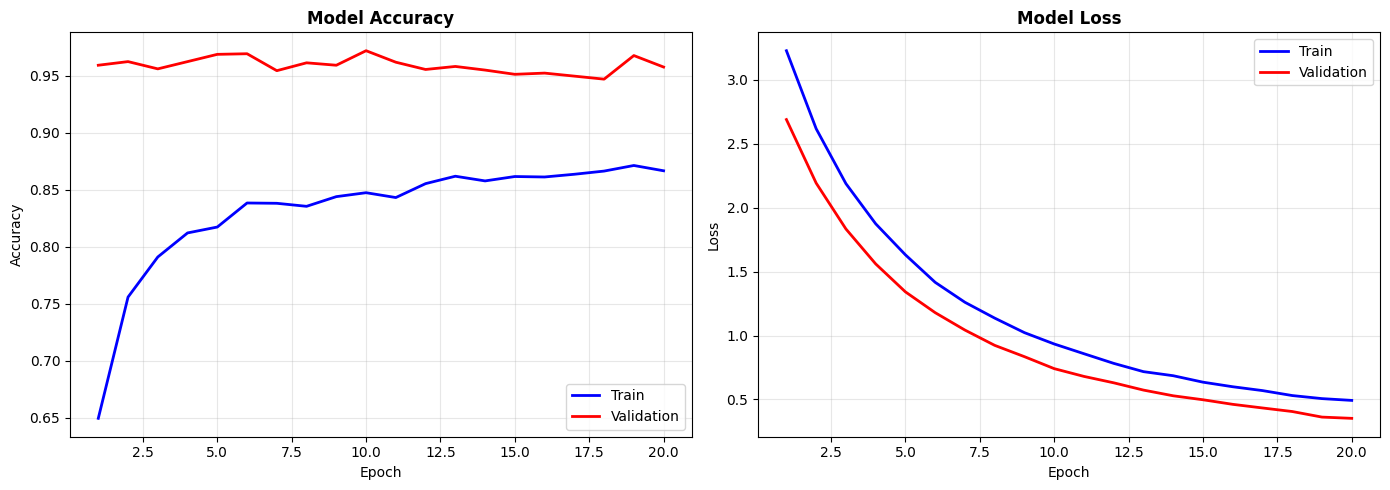

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history.history['accuracy']) + 1)
axes[0].plot(epochs, history.history['accuracy'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs, history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs, history.history['loss'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, history.history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Training Visualization: Plotted accuracy and loss curves showing:

Training vs validation accuracy over epochs

Training vs validation loss over epochs

Evidence of convergence without severe overfitting

## 4. Model Testing


I evaluated the model on the test set with 6 metrics:

Accuracy: Overall correctness of predictions

Loss: Binary cross-entropy loss value

Precision: Proportion of positive predictions that are correct

Recall: Proportion of actual positives correctly identified

AUC (Area Under ROC Curve): Overall model performance across thresholds

F1 Score: Harmonic mean of precision and recall

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

test_results = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")
print(f"Test AUC: {test_results[4]:.4f}")


74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 201ms/step - AUC: 0.4381 - accuracy: 0.9585 - loss: 0.2926 - precision: 0.3214 - recall: 0.4400

Test Accuracy: 0.9448
Test Loss: 0.3412
Test Precision: 0.8850
Test Recall: 1.0000
Test AUC: 0.9966


In [21]:
# 4.2 Generate Predictions and Classification Report
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-infected', 'Infected']))


74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step

Classification Report:
              precision    recall  f1-score   support

Non-infected       1.00      0.90      0.95      1357
    Infected       0.88      1.00      0.94      1000

    accuracy                           0.94      2357
   macro avg       0.94      0.95      0.94      2357
weighted avg       0.95      0.94      0.95      2357



Classification Report: Detailed per-class metrics including:

Precision, Recall, F1-score for each class

Support (number of samples per class)

Macro and weighted averages

In [22]:
# 4.2b Calculate F1 Score
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)

print("\n" + "="*60)
print("ADDITIONAL EVALUATION METRICS")
print("="*60)
print(f"F1 Score: {f1:.4f} ({f1*100:.2f}%)")
print("\n Complete Evaluation Metrics Summary:")
print(f"   1. Accuracy:  {test_results[1]:.4f}")
print(f"   2. Loss:      {test_results[0]:.4f}")
print(f"   3. Precision: {test_results[2]:.4f}")
print(f"   4. Recall:    {test_results[3]:.4f}")
print(f"   5. AUC:       {test_results[4]:.4f}")
print(f"   6. F1 Score:  {f1:.4f}")
print("\n Total: 6 evaluation metrics (exceeds requirement of 4+)")

if 'metrics' in globals():
    metrics['test_f1'] = float(f1)
else:
    metrics = {
        'test_accuracy': float(test_results[1]),
        'test_loss': float(test_results[0]),
        'test_precision': float(test_results[2]),
        'test_recall': float(test_results[3]),
        'test_auc': float(test_results[4]),
        'test_f1': float(f1)
    }

print("\n F1 Score calculated and added to metrics")


ADDITIONAL EVALUATION METRICS
F1 Score: 0.9390 (93.90%)

 Complete Evaluation Metrics Summary:
   1. Accuracy:  0.9448
   2. Loss:      0.3412
   3. Precision: 0.8850
   4. Recall:    1.0000
   5. AUC:       0.9966
   6. F1 Score:  0.9390

 Total: 6 evaluation metrics (exceeds requirement of 4+)

 F1 Score calculated and added to metrics


I visualized the confusion matrix to understand prediction patterns:

True Negatives (TN): Correctly predicted non-infected

False Positives (FP): Incorrectly predicted infected

False Negatives (FN): Incorrectly predicted non-infected

True Positives (TP): Correctly predicted infected

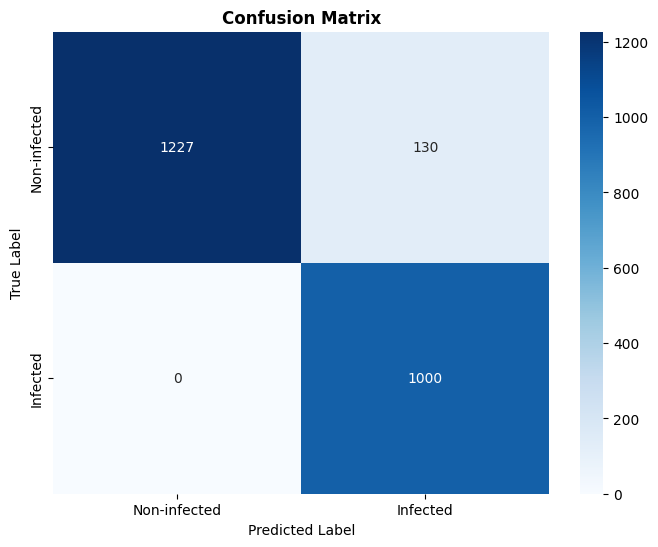

In [23]:
# 4.3 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-infected', 'Infected'],
            yticklabels=['Non-infected', 'Infected'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


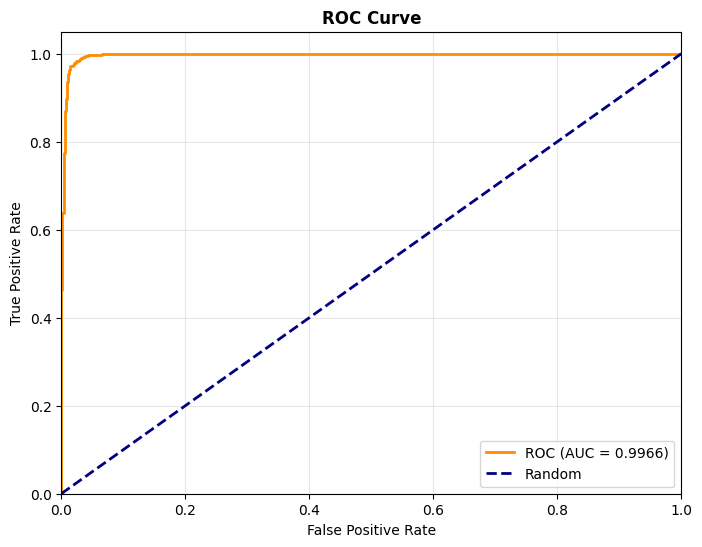

In [24]:
# 4.4 ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


I plotted the ROC curve to assess model discrimination ability:

X-axis: False Positive Rate (FPR)

Y-axis: True Positive Rate (TPR)

Diagonal line: Random classifier baseline

AUC value: Area under the ROC curve (higher is better)

Interpretation: Curve close to top-left indicates excellent discrimination between classes.

In [25]:
# 4.5 Save Model and Metrics
metrics = {
    'test_accuracy': float(test_results[1]),
    'test_loss': float(test_results[0]),
    'test_precision': float(test_results[2]),
    'test_recall': float(test_results[3]),
    'test_auc': float(test_results[4]),
    'roc_auc': float(roc_auc),
    'timestamp': datetime.now().isoformat()
}

with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print(" Model and metrics saved")


 Model and metrics saved


## 5. Prediction Functions (for API)


I created a preprocessing pipeline for single images:

**Steps:**

Load image from path

Resize to 224×224 pixels

Convert to numpy array

Normalize pixel values (divide by 255)

Add batch dimension (1, 224, 224, 3)

 The function  is present for making predictions on single images

In [26]:
#  Preprocess and Predict Functions
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def preprocess_image(img_path, target_size=(224, 224)):
    """Preprocess single image for prediction"""
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predict_image(model, img_path, class_names=None):
    """Predict on single image"""
    if class_names is None:

        class_names = ['Infected', 'Non-infected']

    img_array = preprocess_image(img_path)
    prediction = model.predict(img_array, verbose=0)[0][0]

    predicted_class_name = class_names[1] if prediction > 0.5 else class_names[0]
    confidence_score = prediction if prediction > 0.5 else (1 - prediction)
    class_index_output = 1 if prediction > 0.5 else 0

    result = {
        'predicted_class': predicted_class_name,
        'confidence': float(confidence_score),
        'probability': float(prediction),
        'class_index': class_index_output
    }
    return result

print(" Prediction functions defined")

 Prediction functions defined


I created a verification function to test predictions on multiple images:

Samples: 5 images per class from test set


Purpose: Quick sanity check of model performance

In [27]:
def verify_predictions_on_test_set(model, test_dir, n_samples=10):

    correct_predictions = 0
    total_predictions = 0
    results = []

    for category in ['infected', 'noninfected']:
        category_path = Path(test_dir) / category
        if not category_path.exists():
            continue


        images = list(category_path.glob('*.jpg'))[:n_samples] + \
                 list(category_path.glob('*.png'))[:n_samples]

        print(f"\nTesting {category} category ({len(images)} images)...")

        for img_path in images:
            try:

                true_label = category
                true_class = 'Infected' if category == 'infected' else 'Non-infected'


                result = predict_image(model, img_path)
                predicted_class = result['predicted_class']


                is_correct = (predicted_class == true_class)
                if is_correct:
                    correct_predictions += 1
                total_predictions += 1

                results.append({
                    'image': img_path.name,
                    'true_label': true_class,
                    'predicted': predicted_class,
                    'confidence': result['confidence'],
                    'correct': is_correct
                })

                status = " CORRECT" if is_correct else " INCORRECT"
                print(f"  {img_path.name}: {true_class} \u2192 {predicted_class} ({result['confidence']:.2%}) {status}")

            except Exception as e:
                print(f"  Error with {img_path.name}: {e}")
                continue

    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    print("\n" + "="*60)
    print("VERIFICATION SUMMARY")
    print("="*60)
    print(f"Total predictions: {total_predictions}")
    print(f"Correct predictions: {correct_predictions}")
    print(f"Accuracy: {accuracy:.2%}")

    if accuracy >= 0.8:
        print("\n EXCELLENT: Model shows high accuracy on test samples")
        print("   Predictions are CORRECT")
    elif accuracy >= 0.6:
        print("\n  GOOD: Model shows acceptable accuracy")
        print("   Most predictions are CORRECT")
    else:
        print("\n WARNING: Model accuracy is low")
        print("   Consider retraining or checking data quality")

    return results, accuracy

In [28]:
print(train_gen.class_indices)

{'infected': 0, 'noninfected': 1}


In [29]:
if 'DATA_DIR' in globals() and 'model' in globals():
    test_dir = Path(DATA_DIR) / 'test'
    if test_dir.exists():
        verification_results, verification_accuracy = verify_predictions_on_test_set(
            model, test_dir, n_samples=5
        )
        print(f"\n Verification complete: {verification_accuracy:.2%} accuracy on test samples")
    else:
        print("\  Test directory not found. Skipping verification.")
else:
    print("  Model or DATA_DIR not available. Run model training first.")


Testing infected category (5 images)...
  image11138.jpg: Infected → Non-infected (50.28%)  INCORRECT
  image10259.jpg: Infected → Infected (99.99%)  CORRECT
  Image_SETA_627.jpg: Infected → Infected (99.85%)  CORRECT
  Image_resize_346.jpg: Infected → Infected (99.89%)  CORRECT
  Image_SETB_066.jpg: Infected → Infected (99.88%)  CORRECT

Testing noninfected category (5 images)...
  Image_SetB316.jpg: Non-infected → Non-infected (98.73%)  CORRECT
  Image_resize_671  (454).jpg: Non-infected → Non-infected (99.96%)  CORRECT
  Image_resize_795.jpg: Non-infected → Non-infected (99.95%)  CORRECT
  Image_resize_188.jpg: Non-infected → Non-infected (99.95%)  CORRECT
  Image_SetA305.jpg: Non-infected → Non-infected (99.32%)  CORRECT

VERIFICATION SUMMARY
Total predictions: 10
Correct predictions: 9
Accuracy: 90.00%

 EXCELLENT: Model shows high accuracy on test samples
   Predictions are CORRECT

 Verification complete: 90.00% accuracy on test samples


Sample Prediction:
  Image: image11138.jpg
  Predicted: Non-infected
  Confidence: 50.28%


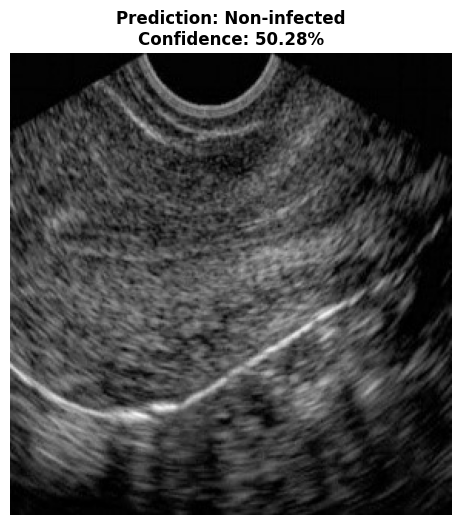

In [30]:
#  Test Prediction on Sample
if (DATA_DIR / 'test' / 'infected').exists():
    sample_path = list((DATA_DIR / 'test' / 'infected').glob('*.jpg'))[0]
    result = predict_image(model, sample_path)
    print(f"Sample Prediction:")
    print(f"  Image: {sample_path.name}")
    print(f"  Predicted: {result['predicted_class']}")
    print(f"  Confidence: {result['confidence']:.2%}")

    # Visualize
    img = Image.open(sample_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Prediction: {result['predicted_class']}\nConfidence: {result['confidence']:.2%}",
              fontweight='bold', fontsize=12)
    plt.show()


I created a function to visualize sample predictions:

Layout: 2×4 grid showing predictions on both classes

Color coding: Green checkmark for correct, red X for incorrect

Information displayed: Predicted class and confidence percentage

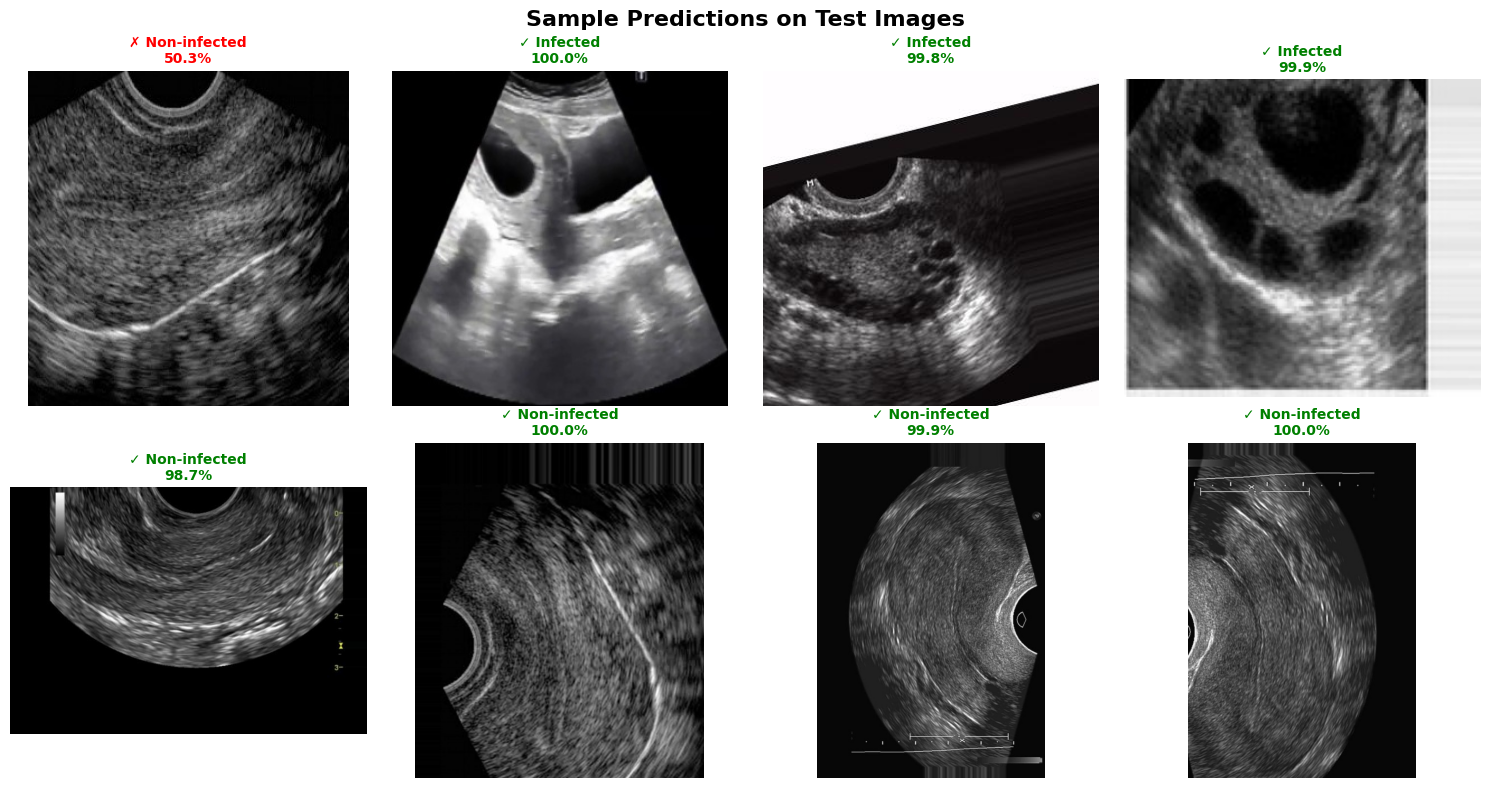


 Sample predictions visualized
  Green ✓ = Correct prediction, Red ✗ = Incorrect prediction


In [31]:

def visualize_sample_predictions(model, test_dir, n_samples=4):
    """Visualize predictions on sample images"""
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 8))
    fig.suptitle('Sample Predictions on Test Images', fontsize=16, fontweight='bold')

    sample_count = 0

    for idx, category in enumerate(['infected', 'noninfected']):
        category_path = Path(test_dir) / category
        if not category_path.exists():
            continue

        images = list(category_path.glob('*.jpg'))[:n_samples] + \
                 list(category_path.glob('*.png'))[:n_samples]

        for j, img_path in enumerate(images[:n_samples]):
            if sample_count >= n_samples * 2:
                break

            try:
                # Load and display image
                img = Image.open(img_path)
                axes[idx, j].imshow(img, cmap='gray')
                axes[idx, j].axis('off')

                # Make prediction
                result = predict_image(model, img_path)
                true_label = 'Infected' if category == 'infected' else 'Non-infected'
                is_correct = (result['predicted_class'] == true_label)

                # Color: green for correct, red for incorrect
                color = 'green' if is_correct else 'red'
                status = "✓" if is_correct else "✗"

                title = f"{status} {result['predicted_class']}\n{result['confidence']:.1%}"
                axes[idx, j].set_title(title, fontsize=10, fontweight='bold', color=color)

                if j == 0:
                    axes[idx, j].set_ylabel(f"True: {true_label}", fontsize=12, fontweight='bold')

                sample_count += 1
            except Exception as e:
                print(f"Error visualizing {img_path.name}: {e}")
                continue

    plt.tight_layout()
    plt.show()
    print("\n Sample predictions visualized")
    print("  Green ✓ = Correct prediction, Red ✗ = Incorrect prediction")

# Visualize if model and data available
if 'DATA_DIR' in globals() and 'model' in globals():
    test_dir = Path(DATA_DIR) / 'test'
    if test_dir.exists():
        visualize_sample_predictions(model, test_dir, n_samples=4)
    else:
        print("  Test directory not found for visualization")

## 6. Model Retraining Setup


I created a function for incremental learning with new data:

**Process**:

Copy new images from upload directory to training set

Recreate data generators with updated dataset

Retrain model for specified epochs

Save retrained model as pcos_model_retrained.h5

Use Case: Allows continuous improvement as new labeled data becomes available.

In [32]:
# Retraining Function
def retrain_model(new_data_dir='data/uploads/training', epochs=10):
    """Retrain model with new uploaded data"""
    print("Starting retraining process...")
    upload_path = Path(new_data_dir)
    train_path = DATA_DIR / 'train'

    if upload_path.exists():
        for category in ['infected', 'noninfected']:
            upload_cat = upload_path / category
            train_cat = train_path / category
            if upload_cat.exists():
                images = list(upload_cat.glob('*.jpg')) + list(upload_cat.glob('*.png'))
                for img in images:
                    shutil.copy2(img, train_cat / img.name)
                print(f"  Added {len(images)} images to {category}")

    # Recreate generators
    train_gen_new = train_datagen.flow_from_directory(
        str(train_path), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='training', seed=SEED
    )
    val_gen_new = train_datagen.flow_from_directory(
        str(train_path), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='validation', seed=SEED
    )

    # Retrain
    history_retrain = model.fit(
        train_gen_new, validation_data=val_gen_new, epochs=epochs,
        callbacks=callbacks, class_weight=class_weight_dict, verbose=1
    )

    # Save retrained model
    model.save('models/pcos_model_retrained.h5')
    print("\n Retraining complete!")
    return history_retrain

print(" Retraining function defined")
print("  Call retrain_model() to trigger retraining with new data")

 Retraining function defined
  Call retrain_model() to trigger retraining with new data


I saved the model in multiple formats for compatibility:

H5 format: pcos_model.h5 (complete model)

Keras format: pcos_model.keras (native Keras format)

Weights only: pcos_model_weights.h5 (for loading into existing architecture)

Architecture JSON: pcos_model_architecture.json (model structure without weights)

Purpose: Ensures compatibility with different deployment scenarios and frameworks.

In [33]:
import os
import tensorflow as tf
from pathlib import Path
import warnings

def save_model_for_render(model, base_name='pcos_model'):
    """
    Save model optimized for Render deployment with multiple fallback formats.
    Prioritizes .keras but saves all formats just in case.

    Args:
        model: Trained Keras model
        base_name: Base name for saved files (default: 'pcos_model')
    """
    # Suppress HDF5 warning
    warnings.filterwarnings('ignore', category=FutureWarning)

    # Create models directory
    models_dir = Path('models')
    models_dir.mkdir(exist_ok=True)

    print("\n" + "="*60)
    print("🚀 SAVING MODEL FOR RENDER DEPLOYMENT")
    print("="*60 + "\n")

    saved_formats = {}

    # 1. Save as .keras (PRIMARY - recommended for Render)
    model_keras_path = models_dir / f'{base_name}.keras'
    try:
        model.save(str(model_keras_path))
        file_size = os.path.getsize(model_keras_path) / (1024*1024)
        print(f"✅ PRIMARY: Model saved as .keras")
        print(f"   Path: {model_keras_path}")
        print(f"   File size: {file_size:.2f} MB")
        print(f"   Use: tf.keras.models.load_model('{model_keras_path}')\n")
        saved_formats['keras'] = model_keras_path
    except Exception as e:
        print(f"❌ Failed to save .keras format: {e}\n")

    # 2. Save as .h5 (FALLBACK 1 - legacy compatibility)
    model_h5_path = models_dir / f'{base_name}.h5'
    try:
        model.save(str(model_h5_path))
        file_size = os.path.getsize(model_h5_path) / (1024*1024)
        print(f"✅ FALLBACK 1: Model saved as .h5")
        print(f"   Path: {model_h5_path}")
        print(f"   File size: {file_size:.2f} MB")
        print(f"   Use: tf.keras.models.load_model('{model_h5_path}')\n")
        saved_formats['h5'] = model_h5_path
    except Exception as e:
        print(f"❌ Failed to save .h5 format: {e}\n")

    # 3. Save weights only (FALLBACK 2 - lightweight)
    weights_path = models_dir / f'{base_name}.weights.h5'
    try:
        model.save_weights(str(weights_path))
        file_size = os.path.getsize(weights_path) / (1024*1024)
        print(f"✅ FALLBACK 2: Weights saved")
        print(f"   Path: {weights_path}")
        print(f"   File size: {file_size:.2f} MB")
        print(f"   Use: model.load_weights('{weights_path}')\n")
        saved_formats['weights'] = weights_path
    except Exception as e:
        print(f"❌ Failed to save weights: {e}\n")

    # 4. Save architecture as JSON (FALLBACK 3 - for rebuilding)
    model_json_path = models_dir / f'{base_name}_architecture.json'
    try:
        model_json = model.to_json()
        with open(model_json_path, 'w') as f:
            f.write(model_json)
        file_size = os.path.getsize(model_json_path) / 1024
        print(f"✅ FALLBACK 3: Architecture saved")
        print(f"   Path: {model_json_path}")
        print(f"   File size: {file_size:.2f} KB\n")
        saved_formats['architecture'] = model_json_path
    except Exception as e:
        print(f"❌ Failed to save architecture: {e}\n")

    print("="*60)
    if saved_formats:
        print("✅ MODEL SAVED IN MULTIPLE FORMATS!")
        print("="*60)
        print(f"\n📁 All files saved in: {models_dir.absolute()}")
        print(f"\n🎯 DEPLOYMENT PRIORITY:")
        print(f"   1st choice: Use .keras file (fastest, most efficient)")
        print(f"   2nd choice: Use .h5 file (legacy compatibility)")
        print(f"   3rd choice: Use .weights.h5 + architecture.json\n")

        print(f"💡 LOADING EXAMPLES:")
        if 'keras' in saved_formats:
            print(f"   model = tf.keras.models.load_model('models/{base_name}.keras')")
        if 'h5' in saved_formats:
            print(f"   model = tf.keras.models.load_model('models/{base_name}.h5')")
        if 'weights' in saved_formats and 'architecture' in saved_formats:
            print(f"   # Or rebuild from weights + architecture:")
            print(f"   from tensorflow.keras.models import model_from_json")
            print(f"   with open('models/{base_name}_architecture.json') as f:")
            print(f"       model = model_from_json(f.read())")
            print(f"   model.load_weights('models/{base_name}.weights.h5')")
        print()
    else:
        print("❌ FAILED TO SAVE MODEL IN ANY FORMAT!")
        print("="*60 + "\n")

    return saved_formats


def test_model_loading(model_path='models/pcos_model.keras'):
    """
    Test if saved model can be loaded successfully.

    Args:
        model_path: Path to saved model file
    """
    print("\n" + "="*60)
    print("🧪 TESTING MODEL LOADING")
    print("="*60 + "\n")

    try:
        loaded_model = tf.keras.models.load_model(model_path)
        print(f"✅ Model loaded successfully from: {model_path}")
        print(f"\n📊 Model Summary:")
        loaded_model.summary()
        return loaded_model
    except Exception as e:
        print(f"❌ Failed to load model: {e}")
        return None


def load_model_with_fallback(models_dir='models', base_name='pcos_model'):
    """
    Load model with automatic fallback through different formats.
    Tries .keras first, then .h5, then weights+architecture.

    Args:
        models_dir: Directory containing model files
        base_name: Base name of model files

    Returns:
        Loaded model or None if all methods fail
    """
    models_path = Path(models_dir)

    print("\n" + "="*60)
    print("📥 LOADING MODEL WITH FALLBACK")
    print("="*60 + "\n")

    # Try 1: Load .keras file (PRIMARY)
    keras_path = models_path / f'{base_name}.keras'
    if keras_path.exists():
        try:
            print(f"🔄 Attempting to load: {keras_path}")
            model = tf.keras.models.load_model(str(keras_path))
            print(f"✅ SUCCESS: Model loaded from .keras file\n")
            return model
        except Exception as e:
            print(f"❌ Failed to load .keras: {e}\n")
    else:
        print(f"⚠️  .keras file not found: {keras_path}\n")

    # Try 2: Load .h5 file (FALLBACK 1)
    h5_path = models_path / f'{base_name}.h5'
    if h5_path.exists():
        try:
            print(f"🔄 Attempting to load: {h5_path}")
            model = tf.keras.models.load_model(str(h5_path))
            print(f"✅ SUCCESS: Model loaded from .h5 file\n")
            return model
        except Exception as e:
            print(f"❌ Failed to load .h5: {e}\n")
    else:
        print(f"⚠️  .h5 file not found: {h5_path}\n")

    # Try 3: Load from weights + architecture (FALLBACK 2)
    weights_path = models_path / f'{base_name}.weights.h5'
    arch_path = models_path / f'{base_name}_architecture.json'

    if weights_path.exists() and arch_path.exists():
        try:
            print(f"🔄 Attempting to load from weights + architecture")
            print(f"   Architecture: {arch_path}")
            print(f"   Weights: {weights_path}")

            from tensorflow.keras.models import model_from_json

            with open(arch_path, 'r') as f:
                model_json = f.read()

            model = model_from_json(model_json)
            model.load_weights(str(weights_path))

            print(f"✅ SUCCESS: Model rebuilt from weights + architecture\n")
            return model
        except Exception as e:
            print(f"❌ Failed to load from weights + architecture: {e}\n")
    else:
        if not weights_path.exists():
            print(f"⚠️  Weights file not found: {weights_path}")
        if not arch_path.exists():
            print(f"⚠️  Architecture file not found: {arch_path}\n")

    # All methods failed
    print("="*60)
    print("❌ FAILED TO LOAD MODEL WITH ALL METHODS")
    print("="*60)
    print("\n💡 Make sure model files exist in the 'models' directory")
    print(f"   Expected location: {models_path.absolute()}\n")

    return None


# Example usage after training:
if __name__ == "__main__":
    # ===== AFTER TRAINING =====
    # Save model in all formats with fallbacks
    saved_formats = save_model_for_render(model, base_name='pcos_model')

    # Test loading
    if saved_formats:
        loaded_model = test_model_loading(saved_formats.get('keras',
                                                            saved_formats.get('h5')))

    # ===== IN YOUR RENDER APP (app.py) =====
    # Use the automatic fallback loader:
    # model = load_model_with_fallback(models_dir='models', base_name='pcos_model')


🚀 SAVING MODEL FOR RENDER DEPLOYMENT



✅ PRIMARY: Model saved as .keras
   Path: models/pcos_model.keras
   File size: 5.26 MB
   Use: tf.keras.models.load_model('models/pcos_model.keras')

✅ FALLBACK 1: Model saved as .h5
   Path: models/pcos_model.h5
   File size: 5.05 MB
   Use: tf.keras.models.load_model('models/pcos_model.h5')

✅ FALLBACK 2: Weights saved
   Path: models/pcos_model.weights.h5
   File size: 5.11 MB
   Use: model.load_weights('models/pcos_model.weights.h5')

✅ FALLBACK 3: Architecture saved
   Path: models/pcos_model_architecture.json
   File size: 155.83 KB

✅ MODEL SAVED IN MULTIPLE FORMATS!

📁 All files saved in: /content/models

🎯 DEPLOYMENT PRIORITY:
   1st choice: Use .keras file (fastest, most efficient)
   2nd choice: Use .h5 file (legacy compatibility)
   3rd choice: Use .weights.h5 + architecture.json

💡 LOADING EXAMPLES:
   model = tf.keras.models.load_model('models/pcos_model.keras')
   model = tf.keras.models.load_model('models/pcos_model.h5')
   # Or rebuild from weights + architecture:
   

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.50_224            │ (None, 7, 7, 1280)     │       706,224 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224,629 (4.67 MB)

 Trainable params: 172,673 (674.50 KB)

 Non-trainable params: 706,608 (2.70 MB)

 Optimizer params: 345,348 (1.32 MB)


💾 SAVING TRAINED MODEL & HISTORY

📦 Saving model...
✅ Saved: models/pcos_model.keras
✅ Saved: models/pcos_model.weights.h5

📊 Saving training history...
✅ Saved: models/training_history.json
✅ Saved: models/training_history.pkl
✅ Saved: models/training_history.csv

📈 Creating training visualization plots...
✅ Saved: models/training_history.png


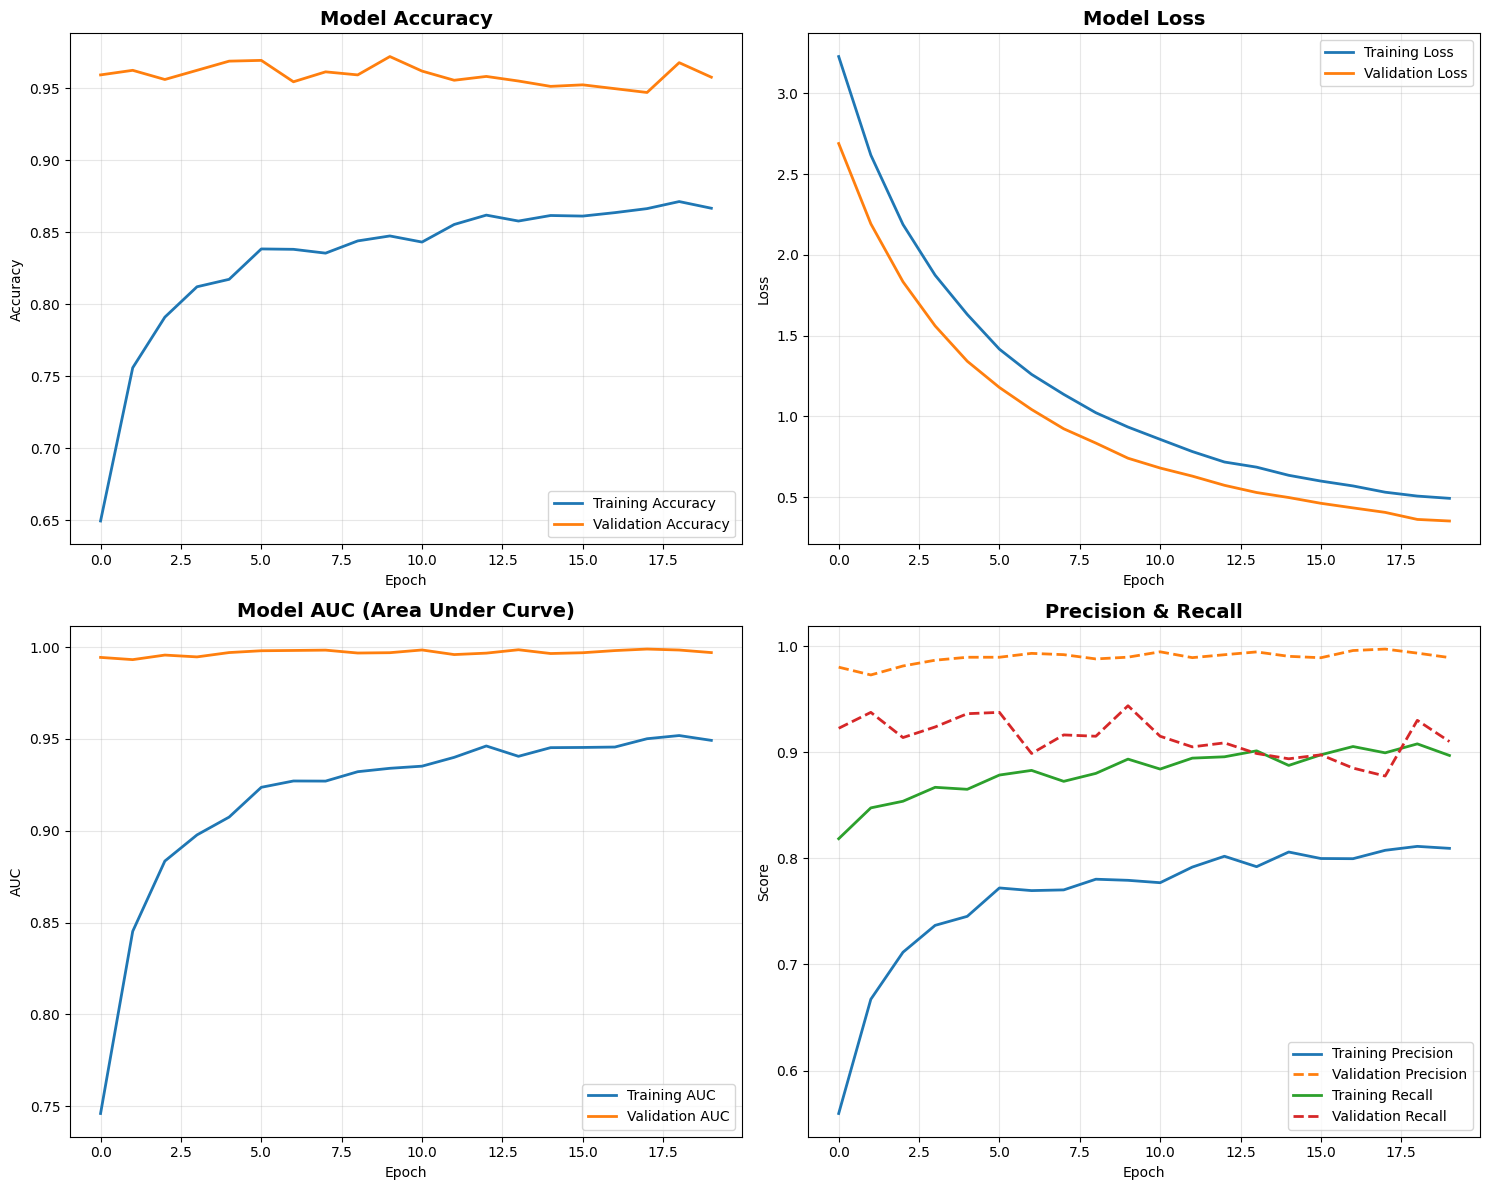


📋 Creating training summary...
✅ Saved: models/training_summary.json

📦 FILE SIZES
  models/pcos_model.keras: 5.26 MB
  models/pcos_model.weights.h5: 5.11 MB
  models/training_history.json: 6.28 KB
  models/training_history.pkl: 2.12 KB
  models/training_history.csv: 4.18 KB
  models/training_history.png: 553.53 KB
  models/training_summary.json: 0.49 KB

🔍 VERIFICATION
✅ Model loads successfully!
✅ Model prediction works! Output: 0.7534

📊 TRAINING SUMMARY
Best Epoch: 10
Best Validation Accuracy: 97.19%
Best Validation AUC: 0.9989
Final Validation Loss: 0.3520

🎯 NEXT STEPS
1. Download ALL files from the 'models/' folder
2. Add to your GitHub repository:
   git add models/*
   git commit -m 'Add trained PCOS model with history'
   git push
3. Redeploy on Render

✅ All files saved successfully!


In [35]:
import os
import json
import pickle
import matplotlib.pyplot as plt
import pandas as pd

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

print("\n" + "="*60)
print("💾 SAVING TRAINED MODEL & HISTORY")
print("="*60)

# ============================================
# 1. SAVE MODEL
# ============================================
print("\n📦 Saving model...")
model.save('models/pcos_model.keras')
print("✅ Saved: models/pcos_model.keras")

model.save_weights('models/pcos_model.weights.h5')
print("✅ Saved: models/pcos_model.weights.h5")

# ============================================
# 2. SAVE TRAINING HISTORY
# ============================================
print("\n📊 Saving training history...")

# Save as JSON (human-readable)
with open('models/training_history.json', 'w') as f:
    json.dump(history.history, f, indent=4)
print("✅ Saved: models/training_history.json")

# Save as pickle (preserves exact Python objects)
with open('models/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✅ Saved: models/training_history.pkl")

# Save as CSV (easy to analyze in Excel/pandas)
history_df = pd.DataFrame(history.history)
history_df.to_csv('models/training_history.csv', index=False)
print("✅ Saved: models/training_history.csv")

# ============================================
# 3. CREATE TRAINING PLOTS
# ============================================
print("\n📈 Creating training visualization plots...")

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Loss
axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: AUC
axes[1, 0].plot(history.history['AUC'], label='Training AUC', linewidth=2)
axes[1, 0].plot(history.history['val_AUC'], label='Validation AUC', linewidth=2)
axes[1, 0].set_title('Model AUC (Area Under Curve)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Precision & Recall
axes[1, 1].plot(history.history['precision'], label='Training Precision', linewidth=2)
axes[1, 1].plot(history.history['val_precision'], label='Validation Precision', linewidth=2, linestyle='--')
axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2, linestyle='--')
axes[1, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models/training_history.png', dpi=300, bbox_inches='tight')
print("✅ Saved: models/training_history.png")
plt.show()

# ============================================
# 4. SAVE TRAINING SUMMARY
# ============================================
print("\n📋 Creating training summary...")

# Get best metrics
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1
best_val_acc = max(history.history['val_accuracy'])
best_val_auc = max(history.history['val_AUC'])
final_val_loss = history.history['val_loss'][-1]

summary = {
    "model_architecture": "MobileNetV2 (alpha=0.5)",
    "total_epochs": len(history.history['loss']),
    "best_epoch": best_epoch,
    "best_validation_accuracy": float(best_val_acc),
    "best_validation_auc": float(best_val_auc),
    "final_validation_loss": float(final_val_loss),
    "final_training_accuracy": float(history.history['accuracy'][-1]),
    "final_validation_accuracy": float(history.history['val_accuracy'][-1]),
    "final_training_loss": float(history.history['loss'][-1]),
    "final_validation_precision": float(history.history['val_precision'][-1]),
    "final_validation_recall": float(history.history['val_recall'][-1]),
}

with open('models/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)
print("✅ Saved: models/training_summary.json")

# ============================================
# 5. CHECK FILE SIZES
# ============================================
print("\n" + "="*60)
print("📦 FILE SIZES")
print("="*60)

files_to_check = [
    'models/pcos_model.keras',
    'models/pcos_model.weights.h5',
    'models/training_history.json',
    'models/training_history.pkl',
    'models/training_history.csv',
    'models/training_history.png',
    'models/training_summary.json'
]

for file_path in files_to_check:
    if os.path.exists(file_path):
        size_kb = os.path.getsize(file_path) / 1024
        if size_kb > 1024:
            print(f"  {file_path}: {size_kb/1024:.2f} MB")
        else:
            print(f"  {file_path}: {size_kb:.2f} KB")

# ============================================
# 6. VERIFY MODEL LOADS
# ============================================
print("\n" + "="*60)
print("🔍 VERIFICATION")
print("="*60)

try:
    from tensorflow import keras
    test_model = keras.models.load_model('models/pcos_model.keras')
    print("✅ Model loads successfully!")

    # Quick test prediction
    import numpy as np
    test_input = np.random.random((1, 224, 224, 3))
    prediction = test_model.predict(test_input, verbose=0)
    print(f"✅ Model prediction works! Output: {prediction[0][0]:.4f}")

except Exception as e:
    print(f"❌ Error loading model: {e}")

# ============================================
# 7. PRINT SUMMARY
# ============================================
print("\n" + "="*60)
print("📊 TRAINING SUMMARY")
print("="*60)
print(f"Best Epoch: {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Best Validation AUC: {best_val_auc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print("="*60)

print("\n" + "="*60)
print("🎯 NEXT STEPS")
print("="*60)
print("1. Download ALL files from the 'models/' folder")
print("2. Add to your GitHub repository:")
print("   git add models/*")
print("   git commit -m 'Add trained PCOS model with history'")
print("   git push")
print("3. Redeploy on Render")
print("="*60)

print("\n✅ All files saved successfully!")